<a href="https://colab.research.google.com/github/Giovanni-Hessel/FIAP-ML-2026/blob/main/CHECKPOINT_%E2%80%93_Machine_Learning_%26_Statistical_Computing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# CHECKPOINT 1 – Machine Learning & Statistical Computing
* Turma: 1TIAPZ-2026 (1º semestre)

* Prepare os dados, separe conjuntos de treino e teste e treine o modelo KNN apresentado em aula.
* Treine o modelo KNN testando diferentes valores de k (por exemplo: k = 1, 3, 5, 7, 9).
* Para cada valor de k, realize a predição no conjunto de teste e calcule a métrica acurácia. Apresente os
resultados em tabela comparativa.

# CHCKPOINT 2 - Statistical Computing
* Utilizando o dataset IRIS, realize uma análise exploratória verificando valores NaN, presença de
outliers e calculando estatísticas descritivas (média, mediana, variância, desvio padrão, mínimo e
máximo). Comente brevemente os resultados.





In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [6]:
#Importando o dataset IRIS
from sklearn.datasets import load_iris
iris = load_iris()
# iris

In [7]:
#Adiciaonado os nomes das colunas dos respectivos dados e transformando em dataframe.
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df["target"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
#Mostrando os valores de target com os respectivos nomes
df_especies = pd.DataFrame([sorted(df['target'].unique())], columns=iris.target_names)
df_especies.head()

,setosa,versicolor,virginica
0,0,1,2


In [9]:
#metadados do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [27]:
#descrendo os dados
#sepal = sépala
#Petal = pétala
#Lenght = Comprimento
#width = Largura
# df.drop(columns = ['target']).describe()

In [29]:
import numpy as np

# Calculando estatísticas descritivas para o dataset IRIS completo (excluindo a coluna 'target')
print("Estatísticas Descritivas para o Dataset IRIS (Total):")

dados_estatisticos_total = df.drop(columns=['target']).agg([
    'mean',
    'median',
    'var',
    'std',
    'min',
    'max'
])
display(dados_estatisticos_total)

Estatísticas Descritivas para o Dataset IRIS (Total):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,5.843333,3.057333,3.758000,1.199333
median,5.800000,3.000000,4.350000,1.300000
var,0.685694,0.189979,3.116278,0.581006
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
max,7.900000,4.400000,6.900000,2.500000


In [28]:
# Calculando estatísticas descritivas agrupadas por tipo de flor ('target')
print("Estatísticas Descritivas por Especie:")

dados_estatisticos_por_especie = df.drop(columns=['target']).groupby(df['target']).agg([
    'mean',
    'median',
    'var',
    'std',
    'min',
    'max'
])
dados_estatisticos_por_especie = dados_estatisticos_por_especie.rename(index=dict(enumerate(iris.target_names)))
display(dados_estatisticos_por_especie)

Estatísticas Descritivas por Tipo de Flor:


sepal length (cm)                                       \
                        mean median       var       std  min  max   
target                                                              
setosa                 5.006    5.0  0.124249  0.352490  4.3  5.8   
versicolor             5.936    5.9  0.266433  0.516171  4.9  7.0   
virginica              6.588    6.5  0.404343  0.635880  4.9  7.9   

           sepal width (cm)                             ... petal length (cm)  \
                       mean median       var       std  ...               var   
target                                                  ...                     
setosa                3.428    3.4  0.143690  0.379064  ...          0.030159   
versicolor            2.770    2.8  0.098469  0.313798  ...          0.220816   
virginica             2.974    3.0  0.104004  0.322497  ...          0.304588   

                               petal width (cm)                             \
                 std  min  max             mean median       var       std   
target                                                                       
setosa      0.173664  1.0  1.9            0.246    0.2  0.011106  0.105386   
versicolor  0.469911  3.0  5.1            1.326    1.3  0.039106  0.197753   
virginica   0.551895  4.5  6.9            2.026    2.0  0.075433  0.274650   

                      
            min  max  
target                
setosa      0.1  0.6  
versicolor  1.0  1.8  
virginica   1.4  2.5  

[3 rows x 24 columns]

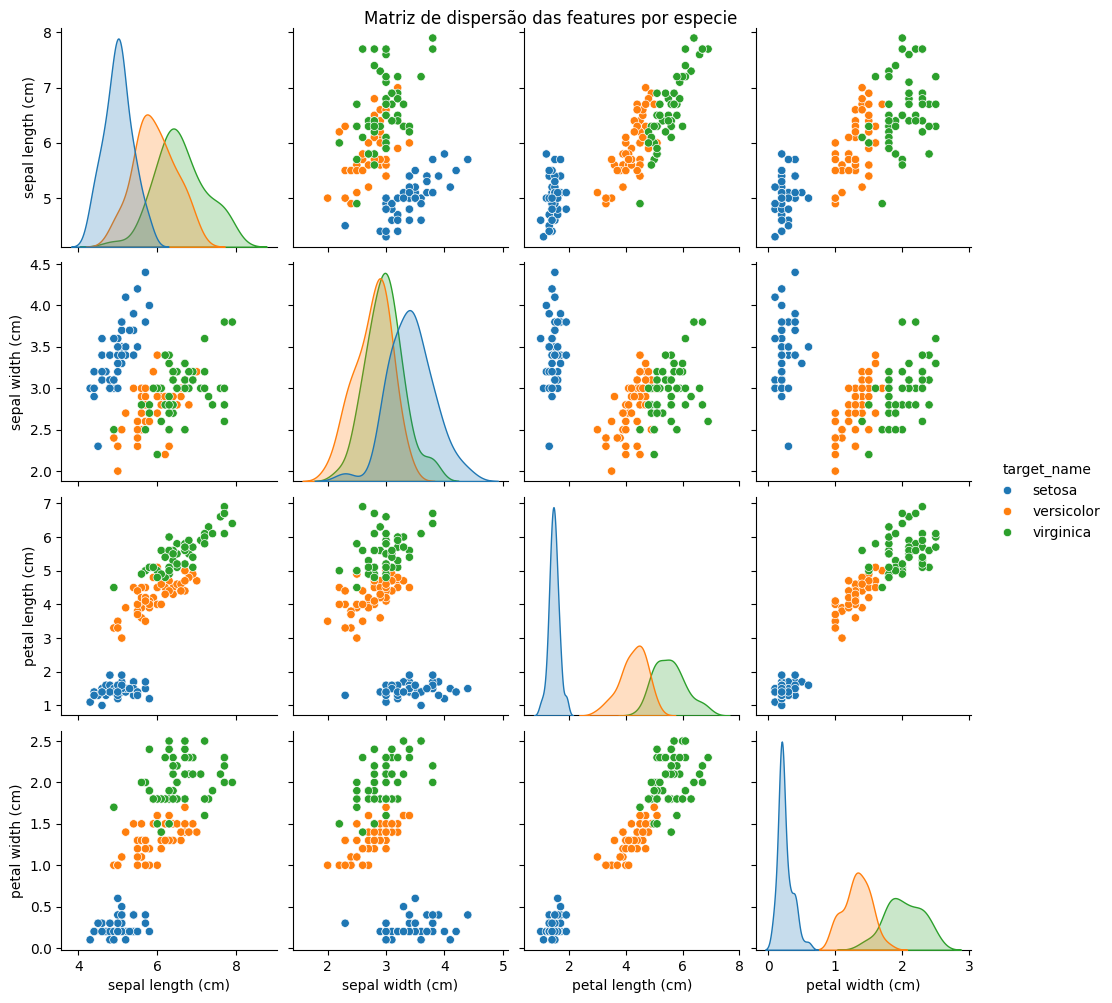

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Copiando o DF e criando uma coluna target_name com os nomes das especies
df_plot = df.copy()
df_plot['target_name'] = df_plot['target'].map(dict(enumerate(iris.target_names)))

# KDE Kernel Density Estimate - outro parametro seria o hist, um histograma.
#Parametro Hue para colorir
#PairPlot é uma matriz de dispersão que visualiza relações par a par entre todas as variáveis numéricas de um conjunto de dados
sns.pairplot(df_plot.drop(columns=['target']), hue='target_name', diag_kind='kde')
plt.suptitle('Matriz de dispersão das features por especie', y=1.0) # Adicionar titulo, y é o local onde vai este titulo, 1 sendo o topo
plt.show()

In [13]:
#Dividindo as features do target
X = iris.data
y = iris.target

#Separando os dados de treino e de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13)

In [14]:
#Treinando com os valores 1,3,5,7,9 fr k, tanto nos pesos uniform e distance.
#Prevendo com os dados que separamos pra teste.
ks  = [1,3,5,7,9]
mls_knn_classifier = []
preds_knn_classifier = []

for k in ks:
  id = "Uniform-K" + str(k)
  ml_knn_classifier = KNeighborsClassifier(n_neighbors = k , weights = 'uniform') #instanciando a classe do KNN
  ml_knn_classifier.fit(X_train, y_train) #treinando
  pred_knn_classifier = ml_knn_classifier.predict(X_test) #testando

  mls_knn_classifier.append({"id": id, 'modelo': ml_knn_classifier}) #modelo treinado
  preds_knn_classifier.append({"id": id, 'modelo': pred_knn_classifier}) #resultado do teste

  id = "Distance-K" + str(k)
  ml_knn_classifier = KNeighborsClassifier(n_neighbors = k , weights = 'distance') #instanciando a classe do KNN
  ml_knn_classifier.fit(X_train, y_train) #treinando
  pred_knn_classifier = ml_knn_classifier.predict(X_test) #testando

  mls_knn_classifier.append({"id": id, 'modelo': ml_knn_classifier}) #modelo treinado
  preds_knn_classifier.append({"id": id, 'modelo': pred_knn_classifier}) #resultado do teste


In [15]:
#Calculando a acuracia e mostrando em tabela
from sklearn.metrics import accuracy_score

laccuracy = []

for pred in sorted(preds_knn_classifier, key=lambda x: x['id']): #iterando os dados ordenados pela coluna id

  #Criando um dicionario para cada linha para apresentar em formato de tabela.
  laccuracy.append({
             "Modelo" : f"KNN Classifier {pred['id']}"
            ,'Qtde_Erros' : int(np.sum(y_test != pred['modelo']))
            ,"Acuracia" : round(accuracy_score(y_test, pred['modelo']),4)
})

#Transformando a lista em um dataframe e mostrando os dados.
df_accuracy = pd.DataFrame(laccuracy)
df_accuracy.head(30)


,Modelo,Qtde_Erros,Acuracia
0,KNN Classifier Distance-K1,2,0.9333
1,KNN Classifier Distance-K3,1,0.9667
2,KNN Classifier Distance-K5,3,0.9000
3,KNN Classifier Distance-K7,1,0.9667
4,KNN Classifier Distance-K9,2,0.9333
5,KNN Classifier Uniform-K1,2,0.9333
6,KNN Classifier Uniform-K3,1,0.9667
7,KNN Classifier Uniform-K5,3,0.9000
8,KNN Classifier Uniform-K7,1,0.9667
9,KNN Classifier Uniform-K9,2,0.9333
